# TD 11 : Révision 


Comme pour le contrôle continu, pour chaque test il est obligatoire de :
1. présenter les données,
2. définir les hypothèses,
3. vérifier les conditions d'application
4. réaliser le test
5. conclure sur les données vis-à-vis de la question posée.

Une réponse ne comprenant pas **toutes** ces étapes là sera considérée comme incomplète et fausse.

## 1. Présentation des données 

Le jeu de données que nous allons utiliser est un extrait de l’enquête ["Histoire de vie" réalisée par l’INSEE en 2003](https://www.insee.fr/fr/statistiques/2532244)
  
<img src="figures/data_TD_entrainnement.jpg" />

L'extrait est disponible dans le fichier *`data_revision.txt`* dans le dossier *`data/`*.
  

## 2. Présentation des données
Présentez rapidement les données, si des valeurs aberrantes sont présentes dans le jeu de données enlever la ou les ligne qui correspond, **en le justifiant**.

In [1]:
revision = read.table("data/data_revision.txt", header = TRUE)
head(revision)
summary(revision)

# Vérification variables qualitatives
table(revision$sexe)
table(revision$nivetud)
table(revision$qualif)
table(revision$clso)
table(revision$trav.imp)
table(revision$trav.satisf)
table(revision$hard.rock)
table(revision$lecture.bd)
table(revision$peche.chasse)
table(revision$cuisine)
table(revision$bricol)
table(revision$cinema)
table(revision$sport)

,id,age,sexe,nivetud,qualif,freres.soeurs,clso,trav.imp,trav.satisf,hard.rock,lecture.bd,peche.chasse,cuisine,bricol,cinema,sport,heures.tv
,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,28,Femme,Enseignement_superieur_y_compris_technique_superieur,Employe,8,Oui,Peu_important,Insatisfaction,Non,Non,Non,Oui,Non,Non,Non,0
2,3,59,Homme,Derniere_annee_d'etudes_primaires,Technicien,2,Non,Aussi_important_que_le_reste,Equilibre,Non,Non,Non,Non,Non,Non,Oui,0
3,4,34,Homme,Enseignement_superieur_y_compris_technique_superieur,Technicien,1,Non,Moins_important_que_le_reste,Satisfaction,Non,Non,Non,Oui,Oui,Oui,Oui,2
4,6,35,Femme,Enseignement_technique_ou_professionnel_court,Employe,5,Non,Le_plus_important,Equilibre,Non,Non,Non,Non,Non,Oui,Oui,2
5,8,47,Homme,Enseignement_technique_ou_professionnel_court,Ouvrier_qualifie,5,Non,Peu_important,Insatisfaction,Non,Non,Oui,Oui,Oui,Non,Non,1
6,10,28,Homme,Enseignement_technique_ou_professionnel_long,Autre,2,Non,Moins_important_que_le_reste,Satisfaction,Non,Non,Non,Non,Non,Oui,Oui,2


       id              age            sexe             nivetud         
 Min.   :   1.0   Min.   : 18.0   Length:934         Length:934        
 1st Qu.: 527.2   1st Qu.: 33.0   Class :character   Class :character  
 Median :1032.0   Median : 41.0   Mode  :character   Mode  :character  
 Mean   :1022.0   Mean   : 40.9                                        
 3rd Qu.:1534.0   3rd Qu.: 49.0                                        
 Max.   :1999.0   Max.   :140.0                                        
    qualif          freres.soeurs        clso             trav.imp        
 Length:934         Min.   : 0.000   Length:934         Length:934        
 Class :character   1st Qu.: 1.000   Class :character   Class :character  
 Mode  :character   Median : 2.000   Mode  :character   Mode  :character  
                    Mean   : 3.151                                        
                    3rd Qu.: 4.000                                        
                    Max.   :22.000            


Femme Homme 
  475   459 


                                                      1er_cycle 
                                                             81 
                                                     2eme_cycle 
                                                            103 
A_arrete_ses_etudes,_avant_la_derniere_annee_d'etudes_primaires 
                                                             13 
                              Derniere_annee_d'etudes_primaires 
                                                             69 
           Enseignement_superieur_y_compris_technique_superieur 
                                                            295 
                  Enseignement_technique_ou_professionnel_court 
                                                            282 
                   Enseignement_technique_ou_professionnel_long 
                                                             84 
                                       N'a_jamais_fait_d'etudes 
                        


                   Autre                    Cadre                  Employe 
                      31                      168                      329 
        Ouvrier_qualifie       Ouvrier_specialise Profession_intermediaire 
                     159                       76                      107 
              Technicien 
                      64 

...


Non Oui 
820 114 


Non Oui 
507 427 


Non Oui 
448 486 


Non Oui 
426 508 


Non Oui 
527 407 

On observe un individu de 140 ans **(!)** et un individu ayant 22 frères et sœurs (c'est possible mais certainement rare).  
Il y a aussi un individu qui dit regarder la télévision 48 heure par jour, ce qui est impossible.  
On va d'abord regarder ces trois individus.

,id,age,sexe,nivetud,qualif,freres.soeurs,clso,trav.imp,trav.satisf,hard.rock,lecture.bd,peche.chasse,cuisine,bricol,cinema,sport,heures.tv
,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
33,67,140,Homme,1er_cycle,Ouvrier_qualifie,2,Oui,Moins_important_que_le_reste,Equilibre,Non,Non,Non,Oui,Oui,Non,Non,4
84,176,39,Femme,Enseignement_superieur_y_compris_technique_superieur,Cadre,3,Non,Moins_important_que_le_reste,Satisfaction,Non,Non,Non,Oui,Oui,Oui,Oui,48
735,1603,34,Femme,1er_cycle,Employe,22,Oui,Moins_important_que_le_reste,Satisfaction,Non,Non,Non,Oui,Non,Oui,Non,2


       id              age            sexe             nivetud         
 Min.   :   1.0   Min.   :18.00   Length:932         Length:932        
 1st Qu.: 529.5   1st Qu.:33.00   Class :character   Class :character  
 Median :1034.5   Median :41.00   Mode  :character   Mode  :character  
 Mean   :1024.0   Mean   :40.79                                        
 3rd Qu.:1535.2   3rd Qu.:49.00                                        
 Max.   :1999.0   Max.   :62.00                                        
    qualif          freres.soeurs        clso             trav.imp        
 Length:932         Min.   : 0.000   Length:932         Length:932        
 Class :character   1st Qu.: 1.000   Class :character   Class :character  
 Mode  :character   Median : 2.000   Mode  :character   Mode  :character  
                    Mean   : 3.152                                        
                    3rd Qu.: 4.000                                        
                    Max.   :22.000            

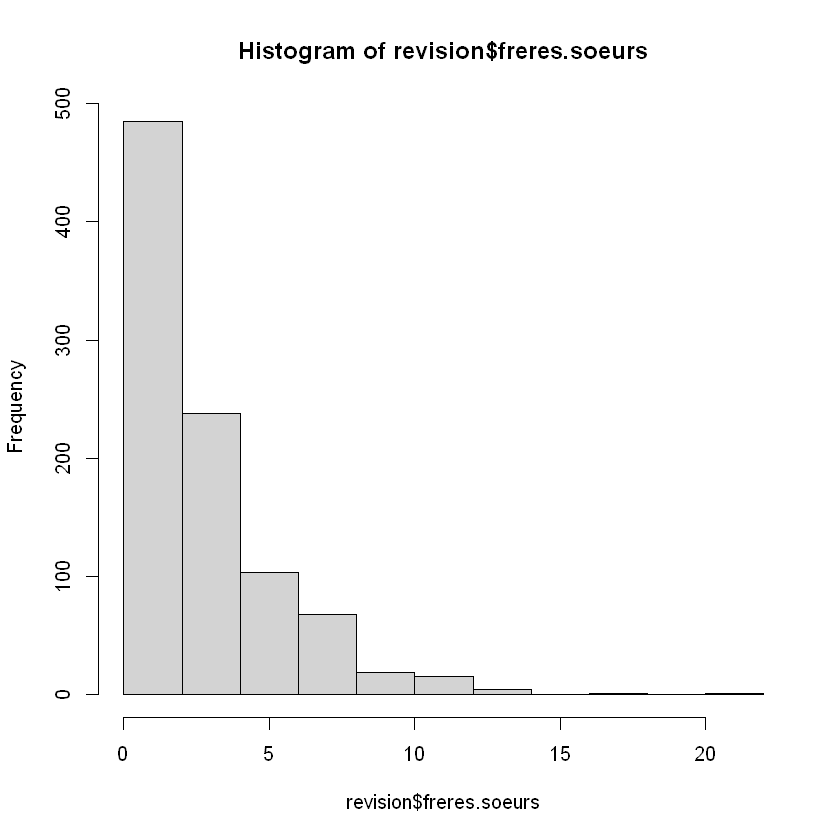

In [2]:
revision[revision$age == 140 | revision$freres.soeurs == 22 | revision$heures.tv == 48,]

hist(revision$freres.soeurs)

# L'individu avec 22 frères et sœurs est seul dans sa catégorie, donc c'est possible
# En revanche pour les deux autres ces points sont faux on va les enlever

revision2 = revision[revision$age < 140 & revision$heures.tv < 48,]
summary(revision2)

# Vérification que les données sont plus logiques

## 3. Statistiques descriptives



1. Quel est le nombre moyen de frères et sœurs des hommes de l'échantillon ?

In [3]:
mean(revision2[revision2$sexe == "Homme", "freres.soeurs"])

[1] 3.183406

2. Quel est l'âge moyen des femmes employées ?

In [4]:
mean(revision2[revision2$sexe == "Femme" & revision2$qualif == "Employe", "age"])

[1] 40.07865

3. Combien y a-t-il de femmes cadres dans l'échantillon ?

In [6]:
length(revision2[revision2$sexe == "Femme" & revision2$qualif == "Cadre", "age"])
dim(revision2[revision2$sexe == "Femme" & revision2$qualif == "Cadre",])

[1] 72

[1] 72 17

4. Combien d'entre elles écoutent du hard rock ?

In [9]:
dim(revision2[revision2$sexe == "Femme" & revision2$qualif == "Cadre" & revision2$hard.rock == "Oui",])

[1]  0 17

5. Quelle est la moyenne et l'écart-type du nombre d'heures de télévision par jour pour les personnes ayant un niveau d'étude égale à `"1er_cycle"` ?

In [12]:
mean(revision2[revision2$nivetud == "1er_cycle", "heures.tv"])
sd(revision2[revision2$nivetud == "1er_cycle", "heures.tv"])

[1] 2.11

[1] 1.786489

## 4. Statistiques inférentielles

a) Existe-t-il une différence de temps passé devant la télévision entre les femmes techniciennes et les femmes cadres au seuil $\alpha = 2\%$ ?

In [15]:
# Sélection des femmes techniciennes et des femmes cadres
femmes_tech  = revision2[revision2$sexe == "Femme" & revision2$qualif == "Technicien",]
femmes_cadre = revision2[revision2$sexe == "Femme" & revision2$qualif == "Cadre",]


# Comparer le temps passé devant la télévision
# -> Comparaison de moyenne
# -> Test de Student
# -> Vérifier conditions d'application (n > 30, sinon normalité & égalité de variance entre échantillons)

nrow(femmes_tech)
nrow(femmes_cadre)
# Moins de 30 femmes techniciennes
# -> On doit vérifier la normalité **des deux**
shapiro.test(femmes_tech$heures.tv)
shapiro.test(femmes_cadre$heures.tv)

# -> Les femmes techniciennes ont une distribution normale des heures de télé au seuil alpha = 2%
# -> Les femmes cadres n'ont pas une distribution normale des heures de télé au seuil alpha = 2%

# Il faut faire un test de Mann-Whitney pour comparer les médianes
# -> pas de conditions d'application

# Hypothèses
# H0 : les femmes techniciennes et les femmes cadres passent le même temps devant la télévision
# H1 : les femmes techniciennes et les femmes cadres passent un temps différent devant la télévision
wilcox.test(femmes_tech$heures.tv, femmes_cadre$heures.tv)

# Au seuil alpha = 2%, on a p = 0.24 > alpha, donc on accepte H0, ce qui signifie qu'on n'observe pas
# de différence dans le temps passé à regarder la télévision entre les femmes cadres et les femmes techniciennes

[1] 13

[1] 72


	Shapiro-Wilk normality test

data:  femmes_tech$heures.tv
W = 0.86096, p-value = 0.03967



	Shapiro-Wilk normality test

data:  femmes_cadre$heures.tv
W = 0.89548, p-value = 2.027e-05



	Wilcoxon rank sum test with continuity correction

data:  femmes_tech$heures.tv and femmes_cadre$heures.tv
W = 372.5, p-value = 0.239
alternative hypothesis: true location shift is not equal to 0


b) Est-ce que le temps passé devant la télévision est supérieur chez les hommes techniciens par rapport aux hommes cadres au seuil $\alpha = 1\%$ ?

In [17]:
# Sélection des femmes techniciennes et des femmes cadres
hommes_tech  = revision2[revision2$sexe == "Homme" & revision2$qualif == "Technicien",]
hommes_cadre = revision2[revision2$sexe == "Homme" & revision2$qualif == "Cadre",]


# Comparer le temps passé devant la télévision
# -> Comparaison de moyenne
# -> Test de Student
# -> Vérifier conditions d'application (n > 30, sinon normalité & égalité des variances entre échantillons)

nrow(hommes_tech)
nrow(hommes_cadre)
# Plus de 30 hommes dans chaque catégorie
# -> On peut faire un test de Student

# Hypothèses
# H0 : les homme techniciens et les hommes cadres passent le même temps devant la télévision
# H1 : les homme techniciens passent un temps supérieur aux hommes cadres devant la télévision
t.test(hommes_tech$heures.tv, hommes_cadre$heures.tv, alternative = "greater")

# Au seuil alpha = 1%, on a p = 7.4⋅10⁻³ < alpha, donc on rejette H0, ce qui signifie qu'on observe
# que les hommes techniciens passent plus de temps devant la télévision que les hommes cadres

[1] 51

[1] 95


	Welch Two Sample t-test

data:  hommes_tech$heures.tv and hommes_cadre$heures.tv
t = 2.4782, df = 99.175, p-value = 0.007446
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 0.1552897       Inf
sample estimates:
mean of x mean of y 
 1.856863  1.386316 


c) Existe-t-il une différence de temps passé devant la télévision chez les hommes en fonction de l'importance accordée au travail au seuil $\alpha = 5\%$ ?  
Si oui, déterminer quel niveau d’importance se distingue des autres.


Aussi_important_que_le_reste            Le_plus_important 
                         136                           10 
Moins_important_que_le_reste                Peu_important 
                         292                           20 


	Kruskal-Wallis rank sum test

data:  hommes$heures.tv and hommes$trav.imp
Kruskal-Wallis chi-squared = 11.658, df = 3, p-value = 0.008652


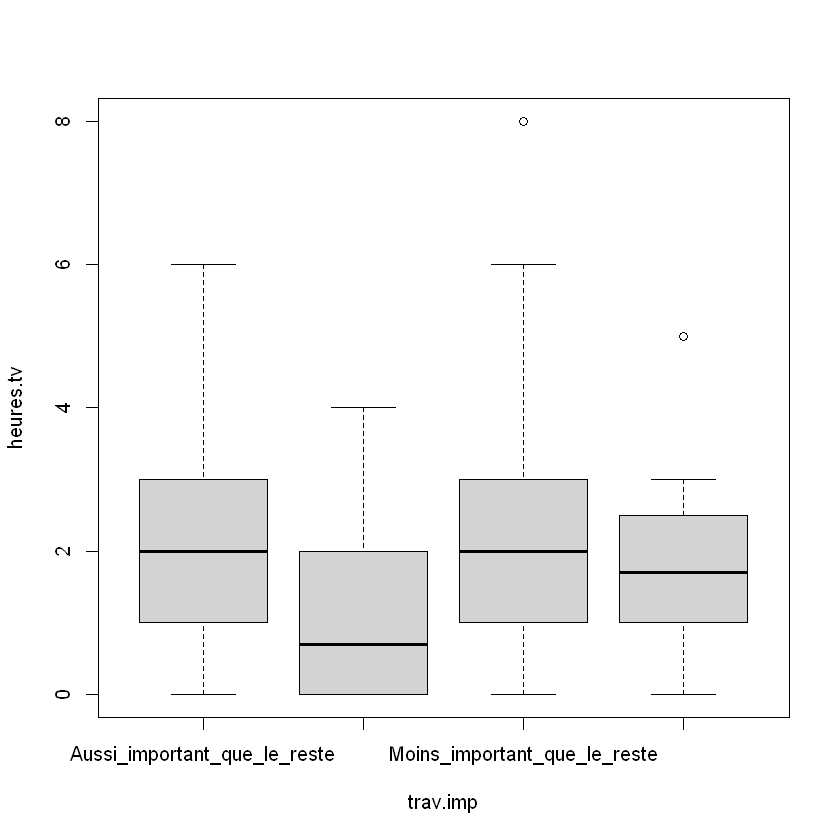

In [21]:
# Sélection des hommes
hommes = revision2[revision2$sexe == "Homme",]

# Comparaison d'une variable quantitative en fonction d'une variable qualitative
# -> 4 groupes d'importance accordée au travail = 4 échantillons indépendants
# -> On doit effectuer un test de Kruskal-Wallis
# -> Pas de condition d'application à vérifier

# Vérification graphique
table(hommes$trav.imp)
boxplot(heures.tv ~ trav.imp, data = hommes)

# Il semble que les personnes pour qui le travail est plus important que le reste
# regardent moins la télévision, sinon les médianes et distributions semblent proches

# Hypothèses du test de Kruskal-Wallis
# H0 : Les distributions de temps passé devant la télévision sont les mêmes entre groupes d'importance accordée au travail
# H1 : Au moins une distribution de temps passé devant la télévision est différente des autres entre groupes d'importance accordée au travail

# Réalisation du test
kruskal.test(hommes$heures.tv, hommes$trav.imp)

# Au seuil alpha = 5%, on observe p = 8.6⋅10⁻³ < alpha, ce qui signifie qu'il y a au moins un groupe d'importance au travail
# qui ne passe pas le même nombre d'heure à regarder la télévision que les autres

In [23]:
## Déterminiation du groupe différent des autres
# On fait l'hypothèse que c'est le groupe pour qui le travail est le plus important
# On réalise des tests de Mann-Whitney entre ce groupe et les autres pour vérifier s'il est bien différent
aussi_imp = hommes[hommes$trav.imp == "Aussi_important_que_le_reste",]
plus_imp  = hommes[hommes$trav.imp == "Le_plus_important",]
moins_imp = hommes[hommes$trav.imp == "Moins_important_que_le_reste",]
peu_imp   = hommes[hommes$trav.imp == "Peu_important",]

# Hypothèses des tests de Mann-Whitney
# H0 : le groupe pour qui le travail est le plus important à une distribution identique à celle de l'autre groupe testé
# H1 : le groupe pour qui le travail est le plus important à une distribution différente à celle de l'autre groupe testé

wilcox.test(plus_imp$heures.tv, aussi_imp$heures.tv)
wilcox.test(plus_imp$heures.tv, moins_imp$heures.tv)
wilcox.test(plus_imp$heures.tv, peu_imp$heures.tv)


	Wilcoxon rank sum test with continuity correction

data:  plus_imp$heures.tv and aussi_imp$heures.tv
W = 469, p-value = 0.09687
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  plus_imp$heures.tv and moins_imp$heures.tv
W = 841, p-value = 0.02025
alternative hypothesis: true location shift is not equal to 0


Warning message in wilcox.test.default(plus_imp$heures.tv, peu_imp$heures.tv):
"impossible de calculer la p-value exacte avec des ex-aequos"



	Wilcoxon rank sum test with continuity correction

data:  plus_imp$heures.tv and peu_imp$heures.tv
W = 71, p-value = 0.2015
alternative hypothesis: true location shift is not equal to 0


d) Existe-t-il une différence de temps passé devant la télévision chez les femmes en fonction de l'importance accordée au travail au seuil $\alpha = 5\%$ ?  
Si oui, déterminer quel niveau d’importance se distingue des autres.


Aussi_important_que_le_reste            Le_plus_important 
                          86                           11 
Moins_important_que_le_reste                Peu_important 
                         345                           32 


	Kruskal-Wallis rank sum test

data:  femmes$heures.tv and femmes$trav.imp
Kruskal-Wallis chi-squared = 2.4804, df = 3, p-value = 0.4788


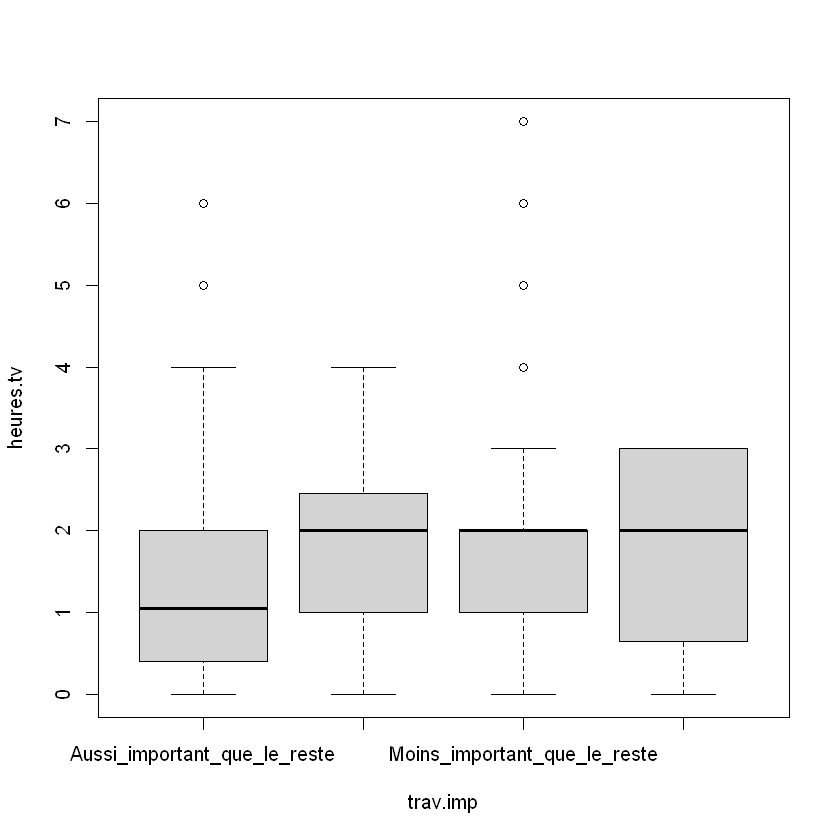

In [25]:
# Sélection des femmes
femmes = revision2[revision2$sexe == "Femme",]

# Comparaison d'une variable quantitative en fonction d'une variable qualitative
# -> On doit effectuer un test de Kruskal-Wallis
# -> Pas de condition d'application à vérifier

# Vérification graphique
table(femmes$trav.imp)
boxplot(heures.tv ~ trav.imp, data = femmes)

# Il semble que les personnes pour qui le travail est plus important que le reste
# regardent moins la télévision, sinon les médianes et distributions semblent proches

# Hypothèses du test de Kruskal-Wallis
# H0 : Les distributions de temps passé devant la télévision sont les mêmes entre groupes d'importance accordée au travail
# H1 : Au moins une distribution de temps passé devant la télévision est différente des autres entre groupes d'importance accordée au travail

# Réalisation du test
kruskal.test(femmes$heures.tv, femmes$trav.imp)

# Au seuil alpha = 5%, on observe p = 0.48 > alpha, ce qui signifie qu'il n'y a
# pas de différence de temps passé devant la télévision en fonction de l'importance
# que les femmes accordent à leur travail

e) Existe-t-il un lien entre le niveau de qualification et le sexe de la personne au seuil $\alpha = 0.001$ ?

In [28]:
# Pas de sélection à faire

# Association entre deux variables qualitatives
# -> test de chi² d'indépendance
# -> Condition d'application = effectifs théoriques > 5

# Observation des données
table(revision2$qualif, revision2$sexe)
# Il semble qu'il y ait plus de femme employées et d'hommes ouvriers qualifiés que l'inverse

# Condition d'application
chisq.test(revision2$qualif, revision2$sexe)$expected
# Tous les effectifs sont > 5, on peut procéder au test

# Hypothèses
# H0 : Il n'y a a pas de lien entre la qualification des personnes et leur sexe
# H1 : Il y a un lien entre la qualification des personnes et leur sexe

# Réalisation du test
chisq.test(revision2$qualif, revision2$sexe)

# Au seuil alpha = 0.001 (= 0.1%), on observe p < alpha, donc on rejette H0, ce qui signifie qu'il y a bien un lien entre la qualification des personnes et leur sexe

                          
                           Femme Homme
  Autre                       17    14
  Cadre                       72    95
  Employe                    267    62
  Ouvrier_qualifie            21   137
  Ouvrier_specialise          32    44
  Profession_intermediaire    52    55
  Technicien                  13    51

,Femme,Homme
Autre,15.76609,15.23391
Cadre,84.93348,82.06652
Employe,167.32403,161.67597
Ouvrier_qualifie,80.35622,77.64378
Ouvrier_specialise,38.65236,37.34764
Profession_intermediaire,54.41845,52.58155
Technicien,32.54936,31.45064



	Pearson's Chi-squared test

data:  revision2$qualif and revision2$sexe
X-squared = 240.7, df = 6, p-value < 2.2e-16


f) Existe-t-il un lien chez les femmes entre la lecture de BD et le cinéma au seuil $\alpha = 5\%$ ?

In [32]:
head(femmes)

# Lien entre deux variables qualitatives : lire des BD et aller au cinéma
# -> il faut faire un chi² d'indépendance
# -> il faut vérifier la condition d'application

# Condition d'application : effectifs théoriques > 5
chisq.test(femmes$lecture.bd, femmes$cinema)$expected
# Tous les effectifs théoriques sont > 5
# -> on peut procéder au test

# Hypothèses :
# H0 : il y a un lien entre la lecture de BD et le fait d'aller au cinéma chez les femmes
# H1 : il n'y a pas de lien
# NB : on ne précise pas la nature du lien, ça peut être que les femmes qui lisent des BD vont au cinéma
#     ou bien qu'au contraire, elles ne vont pas au cinéma par rapport à celles qui ne lisent pas BD

# Réalisation du test
chisq.test(femmes$lecture.bd, femmes$cinema)

# Au seuil alpha = 5%, on observe p = 0.36 > alpha, donc on accepte H0,
# ce qui signifie qu'il n'y a pas de lien entre lecture de BD et cinéma chez les femmes de notre échantillon 

,id,age,sexe,nivetud,qualif,freres.soeurs,clso,trav.imp,trav.satisf,hard.rock,lecture.bd,peche.chasse,cuisine,bricol,cinema,sport,heures.tv
,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,1,28,Femme,Enseignement_superieur_y_compris_technique_superieur,Employe,8,Oui,Peu_important,Insatisfaction,Non,Non,Non,Oui,Non,Non,Non,0.0
4,6,35,Femme,Enseignement_technique_ou_professionnel_court,Employe,5,Non,Le_plus_important,Equilibre,Non,Non,Non,Non,Non,Oui,Oui,2.0
8,16,49,Femme,Enseignement_technique_ou_professionnel_court,Employe,3,Non,Moins_important_que_le_reste,Equilibre,Non,Non,Non,Non,Non,Oui,Non,0.0
9,20,39,Femme,Enseignement_technique_ou_professionnel_court,Ouvrier_qualifie,5,Non,Moins_important_que_le_reste,Satisfaction,Non,Non,Non,Non,Non,Oui,Oui,2.7
10,21,30,Femme,Enseignement_technique_ou_professionnel_court,Employe,6,Oui,Moins_important_que_le_reste,Satisfaction,Non,Non,Non,Oui,Oui,Non,Non,4.0
12,23,37,Femme,Enseignement_technique_ou_professionnel_court,Employe,4,Non,Moins_important_que_le_reste,Satisfaction,Non,Non,Non,Oui,Non,Oui,Oui,0.0


,Non,Oui
Non,192.518987,261.48101
Oui,8.481013,11.51899



	Pearson's Chi-squared test with Yates' continuity correction

data:  femmes$lecture.bd and femmes$cinema
X-squared = 0.83881, df = 1, p-value = 0.3597


g) Existe-t-il un lien chez les hommes entre le bricolage et la pratique du sport au seuil $\alpha = 5\%$ ?

In [35]:
# Idem qu'au-dessus

# -> chi² d'indépendance
chisq.test(hommes$bricol, hommes$sport)$expected
# Condition d'application validée

# Hypothèses :
# H0 : il n'y a pas de lien chez les hommes entre le bricolage et la pratique du sport
# H1 : il y a un lien chez les hommes entre le bricolage et la pratique du sport

chisq.test(hommes$bricol, hommes$sport)
# Au seuil alpha = 5%, on observe p = 0.03 < alpha, donc on rejette H0, et il y a un lien entre le bricolage et la pratique du sport

# En comparant avec le talbeau d'effectifs croisés on pourrait même faire l'hypothèse d'une corrélation positive
table(hommes$bricol, hommes$sport)

,Non,Oui
Non,81.58297,77.41703
Oui,153.41703,145.58297



	Pearson's Chi-squared test with Yates' continuity correction

data:  hommes$bricol and hommes$sport
X-squared = 4.5958, df = 1, p-value = 0.03205


     
      Non Oui
  Non  93  66
  Oui 142 157

h) Est-ce que l'âge des hommes suit une loi gamma de paramètre de forme 14.5 et de paramètre d'échelle 0.35 au seuil $\alpha = 5\%$ ?

In [36]:
# Comparaison d'une variable quantitative à une distribution de loi connue
# -> test de Kolmogorov-Smirnov
# -> pas de condition d'application à vérifier (vive les tests non-paramétriques !)

# Hypothèses :
# H0 : l'âge des hommes suit une loi gamma de paramètre de forme 14.5 et de paramètre d'échelle 0.35
# H1 : l'âge des hommes ne suit pas cette loi

ks.test(hommes$age, "pgamma", 14.5, 0.35)

# Au seuil alpha = 5%, on a p > alpha, donc on accepte H0, et donc l'âge des hommes suit bien un loi gamma de paramètre de forme 14.5 et de paramètre d'échelle 0.35.

Warning message in ks.test.default(hommes$age, "pgamma", 14.5, 0.35):
"aucun ex-aequo ne devrait être présent pour le test de Kolmogorov-Smirnov"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  hommes$age
D = 0.061004, p-value = 0.06615
alternative hypothesis: two-sided


i) Existe-t-il une différence entre le nombre de frères et sœurs lorsque l’on compare les hommes techniciens et les hommes cadres au seuil 5%?

In [39]:
# Comparaison de deux variables quantitatives
# -> test de Student

nrow(hommes_tech)
nrow(hommes_cadre)
# n > 30 dans les deux cas
# -> on peut faire le test directement

# Hypothèses
# H0 : pas de différence en nombre de frères et sœurs
# H1 : il existe une différence

t.test(hommes_tech$freres.soeurs, hommes_cadre$freres.soeurs)

# Au seuil alpha = 5%, on a p = 0.72 > alpha, donc on accepte H0 et il n'y a pas de différence entre le nombre de frères et sœurs
# chez les hommes cadres et techniciens

[1] 51

[1] 95


	Welch Two Sample t-test

data:  hommes_tech$freres.soeurs and hommes_cadre$freres.soeurs
t = 0.3614, df = 102.46, p-value = 0.7185
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.5696877  0.8235577
sample estimates:
mean of x mean of y 
 2.705882  2.578947 


j) Existe-t-il une différence entre le nombre de frères et sœurs lorsque l’on
considère les femmes techniciennes et les femmes cadres au seuil 5%?


	Shapiro-Wilk normality test

data:  femmes_tech$freres.soeurs
W = 0.87027, p-value = 0.05274


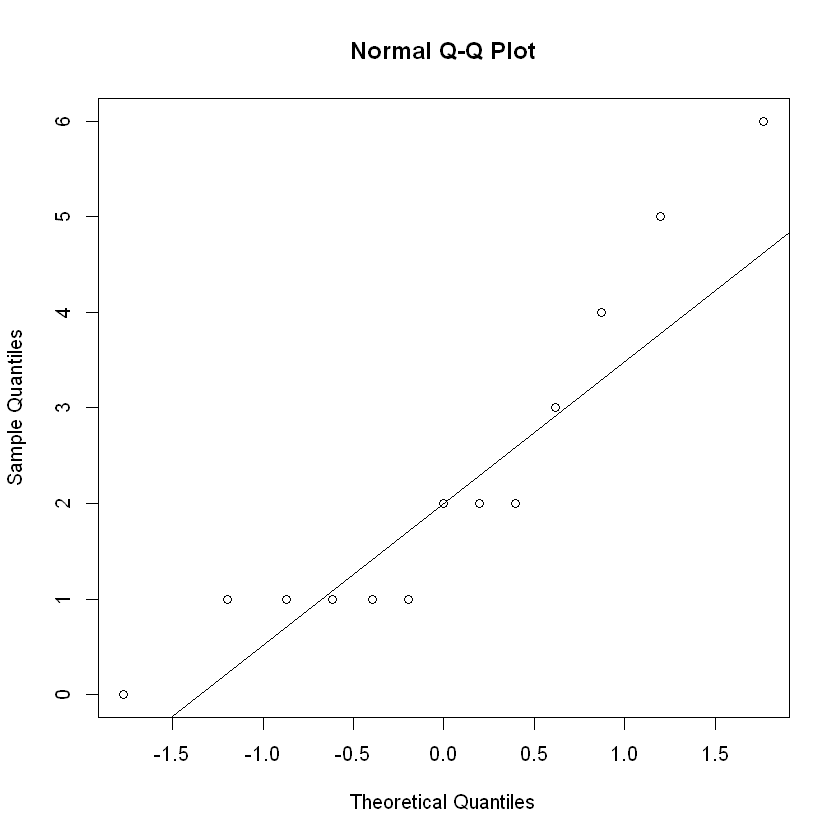


	Shapiro-Wilk normality test

data:  femmes_cadre$freres.soeurs
W = 0.82441, p-value = 8.278e-08



	Wilcoxon rank sum test with continuity correction

data:  femmes_cadre$freres.soeurs and femmes_tech$freres.soeurs
W = 446, p-value = 0.7855
alternative hypothesis: true location shift is not equal to 0


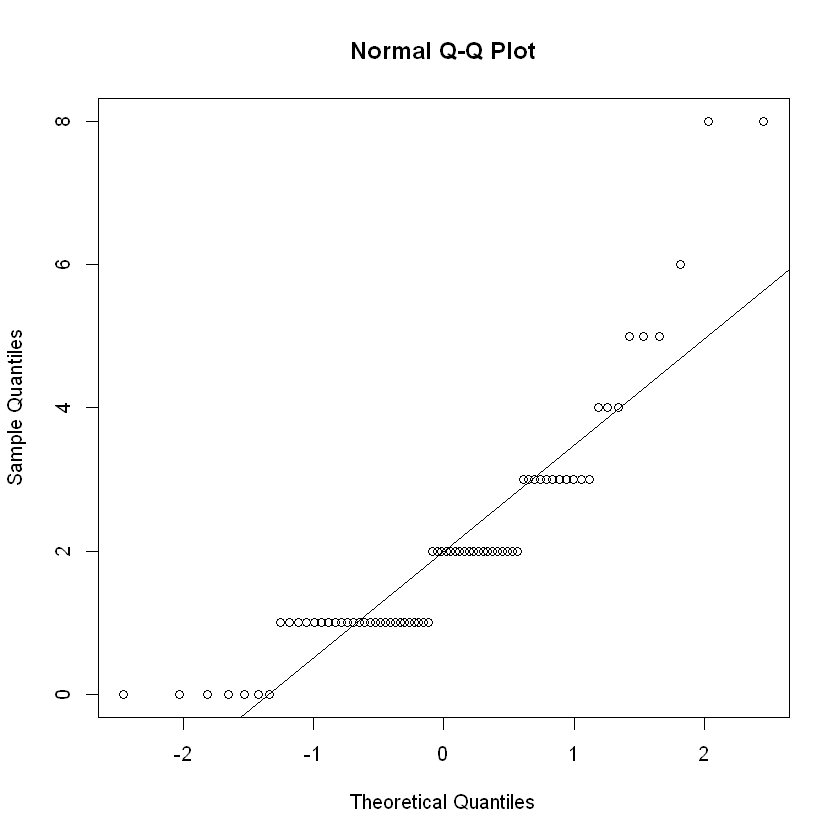

In [45]:
# Comparaison de deux variables quantitatives
# -> test de Student
# On sait déjà que n < 30
# -> il faut vérifier la normalité des deux
qqnorm(femmes_tech$freres.soeurs)
qqline(femmes_tech$freres.soeurs)

shapiro.test(femmes_tech$freres.soeurs)

# -> au seuil alpha = 5%, p = 0.053 > alpha, le nombre de frères et sœurs chez les femmes tech suit une loi normale

qqnorm(femmes_cadre$freres.soeurs)
qqline(femmes_cadre$freres.soeurs)

shapiro.test(femmes_cadre$freres.soeurs)

# -> au seuil alpha = 5%, p = 8.3⋅10⁻̂⁸ < alpha, le nombre de frères et sœurs chez les femmes cadres ne suit pas du tout une loi normale

# Test de Mann-Whitney
# Hypothèses
# H0 : Il existe une différence
# H1 : Il n'existe pas de différence

wilcox.test(femmes_cadre$freres.soeurs, femmes_tech$freres.soeurs)

# Au seuil alpha = 5%, p = 0.79 > alpha, il n'y a pas de différence du nombre de frères et sœurs entre les femmes cadres et les femmes techiciennes

k) Existe-t-il un lien chez les hommes entre la lecture de BD et le cinéma au seuil
5% ?

In [46]:
# idem que là-haut pour les femmes

chisq.test(hommes$lecture.bd, hommes$cinema)$expected
# Il y a deux cas où les effectifs théoriques sont < 5
# -> on ne peut pas procéder au test du chi²

Warning message in chisq.test(hommes$lecture.bd, hommes$cinema):
"L’approximation du Chi-2 est peut-être incorrecte"


,Non,Oui
Non,219.598253,229.401747
Oui,4.401747,4.598253


l) Existe-t-il un lien chez les femmes entre le bricolage et la pratique sport 5% ?

In [49]:
# Mêmes hypothèses et cadre que pour les hommes

table(femmes$bricol, femmes$sport)

chisq.test(femmes$bricol, femmes$sport)$expected
# -> tous les effectifs théoriques > 5

# Hypothèses
# H0 : Pas de lien entre le bricolage et le sport chez les femmes
# H1 : Il existe un lien entre le bricolage et le sport chez les femmes

chisq.test(femmes$bricol, femmes$sport)

# Au seuil alpha = 5%, on a p > alpha, donc on accepte H0, et cela signifie qu'il n'y a pas de lien
# entre bricolage et pratique du sport chez les femmes.

     
      Non Oui
  Non 187 102
  Oui 104  81

,Non,Oui
Non,177.4241,111.57595
Oui,113.5759,71.42405



	Pearson's Chi-squared test with Yates' continuity correction

data:  femmes$bricol and femmes$sport
X-squared = 3.0811, df = 1, p-value = 0.07921


## 5. Quel test choisir ?

Contrairement aux questions précédentes, on ne vous demande pas ici de réaliser les tests, mais uniquement d'**identifier le test statistique approprié** pour répondre à chaque question ci-dessous et de **justifier votre choix** (nature des variables en jeu, nombre de groupes comparés, indépendance ou appariement des échantillons).

Pour chaque situation, répondez en donnant :
1. le nom du test à utiliser,
2. la justification de ce choix (type(s) de variable(s) concernée(s), nombre de groupes, échantillons indépendants ou appariés).

Vous n'avez pas besoin d'exécuter le test ni de connaître la valeur du résultat : l'objectif est uniquement de choisir la bonne méthode.

**Situation 1** : Un chercheur veut savoir si la durée moyenne de sommeil des étudiants de L1 diffère de la durée recommandée de 8 heures.

**Situation 2** : On souhaite comparer le taux de cholestérol de deux groupes de patients indépendants, l'un suivant un régime pauvre en graisses, l'autre un régime standard.

**Situation 3** : Chez les mêmes 20 patients, on mesure la tension artérielle avant et après la prise d'un médicament, et on veut savoir si le médicament a un effet.

**Situation 4** : On veut comparer le temps de récupération après une opération entre quatre hôpitaux différents (quatre groupes de patients indépendants).

**Situation 5** : On veut savoir si le fait de fumer (oui/non) est lié au fait de développer une bronchite chronique (oui/non) dans un échantillon de patients.

**Situation 6** : On dispose de la répartition en pourcentage des groupes sanguins dans la population générale, et on veut savoir si la répartition observée dans un échantillon de donneurs de sang y est conforme.

**Situation 7** : On compare le score de douleur (échelle de 0 à 10, non normalement distribué) rapporté par deux groupes indépendants de patients ayant reçu deux traitements antalgiques différents.

**Situation 8** : On veut comparer le poids de nouveau-nés entre trois maternités différentes, et l'histogramme des poids dans chaque maternité montre une distribution clairement asymétrique (non normale).

*Réponses :*

*Situation 1 : test de Student de comparaison d'une moyenne observée à une moyenne théorique (une seule variable quantitative, comparée à une valeur théorique fixe de 8 heures). Il faut vérifier au préalable la condition de normalité de l'échantillon si n < 30 (TD4).*

*Situation 2 : test de Student de comparaison de deux moyennes indépendantes (variable quantitative, deux groupes indépendants). Conditions d'application à vérifier : normalité de chaque groupe, puis égalité des variances (test de Fisher) pour choisir l'argument `var.equal` (TD5).*

*Situation 3 : test de Student pour données appariées (variable quantitative, mêmes individus mesurés deux fois). Condition d'application à vérifier : normalité de la variable différence (TD6).*

*Situation 4 : test de Kruskal-Wallis (ou ANOVA si les conditions de normalité et d'homogénéité des variances sont vérifiées) : plus de deux groupes indépendants à comparer sur une variable quantitative (TD8).*

*Situation 5 : test du χ² d'indépendance (deux variables qualitatives, on cherche un lien entre elles, pas une comparaison de groupes) (TD10).*

*Situation 6 : test du χ² d'ajustement (une variable qualitative, comparaison des effectifs observés à une distribution théorique de référence) (TD9).*

*Situation 7 : test de Wilcoxon-Mann-Whitney (variable quantitative mais non normalement distribuée, deux groupes indépendants) : c'est l'équivalent non paramétrique du test de Student de la situation 2 (TD7).*

*Situation 8 : test de Kruskal-Wallis (plus de deux groupes indépendants, variable quantitative non normalement distribuée) : c'est l'équivalent non paramétrique de l'ANOVA (TD8).*